# Hábitos de Escucha de Usuarios

En este proyecto, diponemos de datos reales de transmisión de música online para explorar y procesar información sobre los hábitos de escucha de los usuarios y las usuarias en dos ciudades: Springfield y Shelbyville.

## Etapa 1. Descripción de los datos <a id='data_review'></a>

In [1]:
# Importa pandas
import pandas as pd


In [2]:
# Lee el archivo y almacénalo en df
df = pd.read_csv('/content/music_project_en.csv')


In [3]:
# 10 primeras filas de la tabla df
print(df.head(10))

     userID                        Track            artist   genre  \
0  FFB692EC            Kamigata To Boots  The Mass Missile    rock   
1  55204538  Delayed Because of Accident  Andreas Rönnberg    rock   
2    20EC38            Funiculì funiculà       Mario Lanza     pop   
3  A3DD03C9        Dragons in the Sunset        Fire + Ice    folk   
4  E2DC1FAE                  Soul People        Space Echo   dance   
5  842029A1                       Chains          Obladaet  rusrap   
6  4CB90AA5                         True      Roman Messer   dance   
7  F03E1C1F             Feeling This Way   Polina Griffith   dance   
8  8FA1D3BE                     L’estate       Julia Dalia  ruspop   
9  E772D5C0                    Pessimist               NaN   dance   

        City        time        Day  
0  Shelbyville  20:28:33  Wednesday  
1  Springfield  14:07:09     Friday  
2  Shelbyville  20:58:07  Wednesday  
3  Shelbyville  08:37:09     Monday  
4  Springfield  08:34:34     Monday  
5

In [4]:
# Información general sobre nuestros datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65079 entries, 0 to 65078
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0     userID  65079 non-null  object
 1   Track     63736 non-null  object
 2   artist    57512 non-null  object
 3   genre     63881 non-null  object
 4     City    65079 non-null  object
 5   time      65079 non-null  object
 6   Day       65079 non-null  object
dtypes: object(7)
memory usage: 3.5+ MB



1. Según el método info, las columas en su totalidad tienen datos de tipo object en sus filas. Podemos reconocerlo por el método info así como la propieda dtypes

2. Con el método info podemos ver las cabeceras y con ello ver los espacios que presentan algunas de ellas así como que no hay homogeneidad en el capital letter de ellas.

3. En el head sólo vi como inusual un id que es algo más corto que los demás, pero con el método info veo que en las columnas Track, artist y genre hay valores nulos.

## Etapa 2. Preprocesamiento de los datos <a id='data_preprocessing'></a>


### Estilo del encabezado <a id='header_style'></a>

In [5]:
# Muestra los nombres de las columnas
print(df.columns)

Index(['  userID', 'Track', 'artist', 'genre', '  City  ', 'time', 'Day'], dtype='object')


Vamos cambiar los encabezados de la tabla siguiendo las reglas estilísticas convencionales:
*   Colocar todos los caracteres deben ser minúsculas.
*   Eliminar los espacios.
*   Si el nombre tiene varias palabras, utiliza snake_case, es decir, añadir un guion bajo ( _ ) entre las palabras en lugar de un espacio.


In [6]:
# Bucle que itera sobre los encabezados y los pone todos en minúsculas

new_columns = []
for column in df.columns :
    new_columns.append(column.lower())
df.columns = new_columns

In [7]:
# Bucle que itera sobre los encabezados y elimina los espacios

new_columns = []
for column in df.columns :
    new_columns.append(column.strip())
df.columns = new_columns


In [8]:
# Cambia el nombre de la columna "userid"
new_columns = []
for column in df.columns :
    new_columns.append(column.replace('userid', 'user_id'))
df.columns = new_columns

In [9]:
# Comprueba el resultado: lista de encabezados
print(df.columns)

Index(['user_id', 'track', 'artist', 'genre', 'city', 'time', 'day'], dtype='object')


### Valores ausentes <a id='missing_values'></a>

In [10]:
# Calcula el número de valores ausentes
print(df.isna().sum())

user_id       0
track      1343
artist     7567
genre      1198
city          0
time          0
day           0
dtype: int64


In [11]:
# Bucle en los encabezados reemplazando los valores ausentes con 'unknown'
columns_to_replace = ['track', 'artist', 'genre']

for column in columns_to_replace:
    # Corregido: Asignación directa en lugar de inplace=True
    df[column] = df[column].fillna('unknown')


In [12]:
# Cuenta los valores ausentes
print(df.isna().sum())

user_id    0
track      0
artist     0
genre      0
city       0
time       0
day        0
dtype: int64


### Duplicados <a id='duplicates'></a>

In [13]:
# Cuenta los duplicados explícitos
print(df.duplicated().sum())

3826


In [14]:
# Elimina los duplicados explícitos
df.drop_duplicates(inplace=True)



In [15]:
# Comprueba de nuevo si hay duplicados
print(df.duplicated().sum())

0


Ahora queremos deshacernos de los duplicados implícitos en la columna `genre`. Por ejemplo, el nombre de un género se puede escribir de varias formas. Dichos errores también pueden afectar al resultado.

In [16]:
# Inspecciona los nombres de géneros únicos
df_genre = df['genre']
df_uniques_genres = df_genre.unique()
print(sorted(df_uniques_genres))

['acid', 'acoustic', 'action', 'adult', 'africa', 'afrikaans', 'alternative', 'ambient', 'americana', 'animated', 'anime', 'arabesk', 'arabic', 'arena', 'argentinetango', 'art', 'audiobook', 'avantgarde', 'axé', 'baile', 'balkan', 'beats', 'bigroom', 'black', 'bluegrass', 'blues', 'bollywood', 'bossa', 'brazilian', 'breakbeat', 'breaks', 'broadway', 'cantautori', 'cantopop', 'canzone', 'caribbean', 'caucasian', 'celtic', 'chamber', 'children', 'chill', 'chinese', 'choral', 'christian', 'christmas', 'classical', 'classicmetal', 'club', 'colombian', 'comedy', 'conjazz', 'contemporary', 'country', 'cuban', 'dance', 'dancehall', 'dancepop', 'dark', 'death', 'deep', 'deutschrock', 'deutschspr', 'dirty', 'disco', 'dnb', 'documentary', 'downbeat', 'downtempo', 'drum', 'dub', 'dubstep', 'eastern', 'easy', 'electronic', 'electropop', 'emo', 'entehno', 'epicmetal', 'estrada', 'ethnic', 'eurofolk', 'european', 'experimental', 'extrememetal', 'fado', 'film', 'fitness', 'flamenco', 'folk', 'folklor

In [17]:
# Función para reemplazar los duplicados implícitos
def replace_wrong_values(df, column, wrong_values, correct_value):
    for wrong_value in wrong_values:
        df[column] = df[column].replace(wrong_value, correct_value)




In [18]:
# Elimina los duplicados implícitos
wrong_values = ['hip', 'hop', 'hip-hop']
replace_wrong_values(df, 'genre', wrong_values, 'hiphop')

In [19]:
# Comprueba de nuevo los duplicados implícitos
print(sorted(df['genre'].unique()))

['acid', 'acoustic', 'action', 'adult', 'africa', 'afrikaans', 'alternative', 'ambient', 'americana', 'animated', 'anime', 'arabesk', 'arabic', 'arena', 'argentinetango', 'art', 'audiobook', 'avantgarde', 'axé', 'baile', 'balkan', 'beats', 'bigroom', 'black', 'bluegrass', 'blues', 'bollywood', 'bossa', 'brazilian', 'breakbeat', 'breaks', 'broadway', 'cantautori', 'cantopop', 'canzone', 'caribbean', 'caucasian', 'celtic', 'chamber', 'children', 'chill', 'chinese', 'choral', 'christian', 'christmas', 'classical', 'classicmetal', 'club', 'colombian', 'comedy', 'conjazz', 'contemporary', 'country', 'cuban', 'dance', 'dancehall', 'dancepop', 'dark', 'death', 'deep', 'deutschrock', 'deutschspr', 'dirty', 'disco', 'dnb', 'documentary', 'downbeat', 'downtempo', 'drum', 'dub', 'dubstep', 'eastern', 'easy', 'electronic', 'electropop', 'emo', 'entehno', 'epicmetal', 'estrada', 'ethnic', 'eurofolk', 'european', 'experimental', 'extrememetal', 'fado', 'film', 'fitness', 'flamenco', 'folk', 'folklor

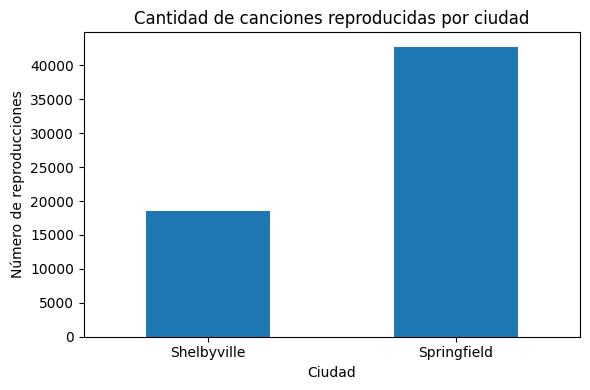

In [20]:
import matplotlib.pyplot as plt

# Cantidad de canciones reproducidas por ciudad
tracks_por_ciudad = df.groupby('city')['track'].count()

# Gráfico
plt.figure(figsize=(6,4))
tracks_por_ciudad.plot(kind='bar')

plt.title('Cantidad de canciones reproducidas por ciudad')
plt.xlabel('Ciudad')
plt.ylabel('Número de reproducciones')
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

## Etapa 3. Análisis

Queremos analizar si hay diferencias en la cantidad de canciones reproducidas en Springfield y Shelbyville. Para ello, usaremos los datos de dos días de la semana: lunes y viernes.

Compararemos cuántas canciones se escucharon en cada ciudad durante esos días para identificar posibles patrones de comportamiento.

In [21]:
# Cuenta las canciones reproducidas en cada ciudad
print(df.groupby('city')['track'].count())

city
Shelbyville    18512
Springfield    42741
Name: track, dtype: int64


El número de tracks reproducidas en SpringField es mayor al número de tracks reproducidos en Shelbyville.

In [22]:
# Calcula las canciones reproducidas en cada uno de los dos días
print(df.groupby('day')['track'].count())

day
Friday       21840
Monday       21354
Wednesday    18059
Name: track, dtype: int64


Sería interesante saber si en cada ciudad estos datos son diferentes o es algo general que en todas las ciudades ocurre lo del día. Se me hace interesante como esto puede llevarse a otro nivel viendo las diferencias culturales en cuanto a como podría variar en referencia a los días.

In [23]:

def number_tracks(day, city):
    return df.query("day == @day & city == @city")['user_id'].count()

In [24]:

# El número de canciones reproducidas en Springfield el lunes
number_tracks('Monday', 'Springfield')


np.int64(15740)

In [25]:
# El número de canciones reproducidas en Shelbyville el lunes
number_tracks('Monday', 'Shelbyville')

np.int64(5614)

In [26]:
# El número de canciones reproducidas en Springfield el viernes
number_tracks('Friday', 'Springfield')

np.int64(15945)

In [27]:
# El número de canciones reproducidas en Shelbyville el viernes
number_tracks('Friday', 'Shelbyville')

np.int64(5895)

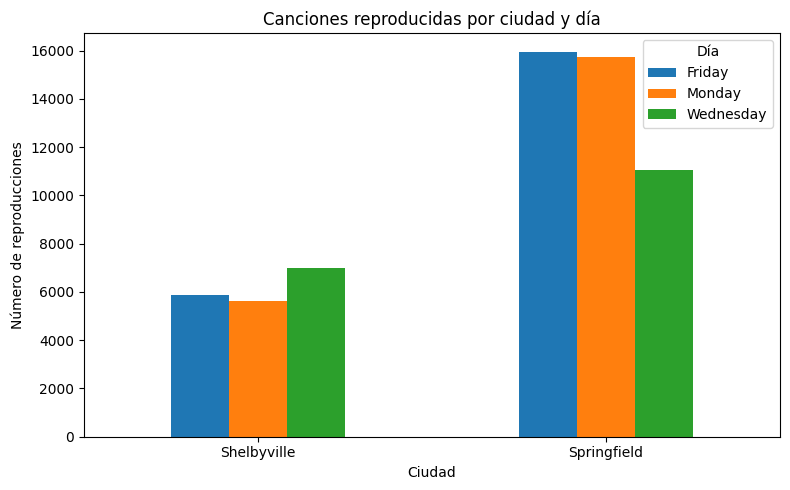

In [28]:
# Canciones por ciudad y día
city_day = df.groupby(['city', 'day'])['track'].count().unstack()

# Gráfico
city_day.plot(kind='bar', figsize=(8,5))

plt.title('Canciones reproducidas por ciudad y día')
plt.xlabel('Ciudad')
plt.ylabel('Número de reproducciones')
plt.xticks(rotation=0)
plt.legend(title='Día')
plt.tight_layout()

plt.show()

# Conclusiones <a id='end'></a>

En base a los datos finales encontrados podemos observar que en SpringField se suele escuchar más música que en Shelvyville y que por otro lado las personas suelen escuchar música de preferencia los viernes antes que los lunes. Es interesante ver que considerando en días como el miércoles, la cantidad de canciones es mucho menor por lo que sería interesante compararlo con otros datos para ver la razón de este comportamiento.


Por otra parte, los datos sí desmuestran un cambio en cuanto a las ciudades ya que este comportamiento es normal ya que el aspecto cultural puede modificar la manera en la que las personas se distraen. Sin embargo, algo curioso es que aún así en cuanto a los días, vemos un patrón que también llama la atención. Sería bueno ver si ese patrón se extiende más allá de las ciudades evaluadas y se repite a nivel del país o del continente.